In [1]:
import os
if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0 # Use "" to use the CPU
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Import Sionna
try:
    import sionna.phy
except ImportError as e:
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

# Configure the notebook to use only a single GPU and allocate only as much memory as needed
# For more details, see https://www.tensorflow.org/guide/gpu
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)
# Avoid warnings from TensorFlow
tf.get_logger().setLevel('ERROR')

# Set random seed for reproducibility
#sionna.phy.config.seed = 42

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import time

from sionna.phy import Block
from sionna.phy.mapping  import BinarySource,QAMSource,SymbolDemapper,Constellation
from sionna.phy.mimo import StreamManagement,KBestDetector
from sionna.phy.ofdm import ResourceGrid, ResourceGridMapper, \
                            LSChannelEstimator, LMMSEEqualizer, \
                            RemoveNulledSubcarriers,LinearDetector
from sionna.phy.channel.tr38901 import Antenna, AntennaArray, UMi, UMa, RMa
from sionna.phy.channel import gen_single_sector_topology as gen_topology
from sionna.phy.channel import subcarrier_frequencies, cir_to_ofdm_channel, AWGN,ApplyOFDMChannel, OFDMChannel,CIRDataset
from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder
from sionna.phy.mapping import Mapper, Demapper, BinarySource, QAMSource
from sionna.phy.utils import ebnodb2no, sim_ber, compute_ber,PlotBER
from sionna.phy.nr import PUSCHConfig, PUSCHTransmitter, PUSCHReceiver
from sionna.phy.fec.polar import PolarEncoder, Polar5GEncoder, PolarSCLDecoder, Polar5GDecoder


from sionna.rt import load_scene, Camera, Transmitter, Receiver, PlanarArray,\
                      PathSolver, RadioMapSolver

no_preview = True # Toggle to False to use the preview widget
                  # instead of rendering for scene visualization

In [3]:
# System parameters
subcarrier_spacing = 30e3 # Hz
num_time_steps = 14 # Total number of ofdm symbols per slot

num_tx = 16 # Number of Ap
num_rx = 1 # Only one receiver considered ue 
num_tx_ant = 1 # Each user has 4 antennas
num_rx_ant = 1 # The receiver is equipped with 16 antennas

# batch_size for CIR generation
batch_size_cir = 1  #by değer başlangıçta bir alınır ki her tx için bir olası rx konumu üretsin toplan 16 ap için olası 16 ue konumu
fft_size=128   #ofdm channel subcarrier number 

In [4]:

scene = load_scene(sionna.rt.scene.munich)

min_x, max_x = 0, 400
min_y, max_y = 0, 400
ap_height = 10 

x_coords = np.linspace(min_x, max_x, 4)  #apler düzenli grid şeklinde yerleştirildi. 
y_coords = np.linspace(min_y, max_y, 4)

positions = []
for x in x_coords:
    for y in y_coords:
        positions.append([x, y, ap_height])  

positions = np.array(positions)


scene.tx_array = PlanarArray(num_rows=1,     # tx veya rx için ayrı ayrı sadece bir adet planarray belirlenbebilir . sahadaki tüm rx ler kendi içinde özdeş, sahadaki tüm tx ler de kendi içinde özdeştir. 
                             num_cols=1, # We want to transmitter to be equiped with 16 antennas. bu sayı yatayda kaç adet anten boşluğu verdiğimnizi belirler. 
                             vertical_spacing=0.5, #elemanlar arası dikeydeki dalga boyu mesafesi. yani yarım dalga boyu mesafe 
                             horizontal_spacing=0.5,
                             pattern="tr38901", #bu pattern yönlü anten paternidir. 360 derece kapsamaz. dipole olsaydı 360 derece olurdu. 
                             polarization="V")  #vertical placement. cross olsaydı tüm yukarıdaki ayarlar aynı kalsa bile her apdeki anten sayısı 2 yre çıkmış olurrdu. 5G de genelde cross kullanılır. 

for i in range(num_tx):
    scene.remove(f"tx-{i}") # Remove old receiver if any
    tx = Transmitter(name=f"tx-{i}", #burada herhangi bir hız vektörü yok olayısı ile txden kaynaklı bir doppler kaymasından oturu faz kayması gerceklesmez. 
                  position=positions[i], # Position sampled from radio map. ilk pozisyon (0,0) noktası olur. dolayısı ile ap0 bu noktaya yerleştirildi.
                  display_radius=3., # optional, radius of the sphere for visualizing the device
                  color=(1,0,0) # optional, color for visualizing the device
                  )
    scene.add(tx)

# Create new camera
bird_cam = Camera(position=[0,80,1000] , orientation=np.array([0,np.pi/2,-np.pi/2]))  # position:kameranın sahnedekı konumu, orientation ise hangi yöne baktıüğını ve nasıl durdugunu belirler. 


In [5]:
max_depth = 5  #tx den çıkan bir ışının maksimum yansıma sayısı. 

# Radio map solver
rm_solver = RadioMapSolver()

# Compute the radio map
rm = rm_solver(scene,
               max_depth=max_depth,
               cell_size=(1., 1.), #hesaplamanın yapıldıgı ızgaranın çözünürlüğüdür. işlem şu şekilde gerçekleşir. bizim 499x400 alanımız 1x1 lik karelere bölünür. bu 10 milyon ışının ulaştığı her karedeki gücü hesaplanır. seçilen oe pozisyonu hangi karede ise o kareye ait ulasşa ışınlar ve güç o uenin beri için kullanılır. 
               samples_per_tx=10**7)  #her apden dışarı çıkan ışın sayısıdır. burada 10 milyon olarak belirledik. 




In [6]:
"""
if no_preview:
    # Render an image
    scene.render(camera=bird_cam,  #scene render sahnenin yüksek kaliteli statik fotoğrafını çeker. 
                 radio_map=rm, # hesaplanan sinyal gücü haritası 
                 rm_vmin=-110,
                 clip_at=12.); # Clip the scene at rendering for visualizing the refracted field
else:
    # Show preview
    scene.preview(radio_map=rm,  # scne preview etkileşimli interaktif pencere açar. 
                  rm_vmin=-110, #-110 dBm'den daha zayıf olan sinyalleri 'yok' say ve gösterme. çünkü modern cihazların sınırı budur. 
                  clip_at=12.); # Görüntüyü yerden 12 metre yükseklikte yatay olarak kes (tıraşla).

"""

"\nif no_preview:\n    # Render an image\n    scene.render(camera=bird_cam,  #scene render sahnenin yüksek kaliteli statik fotoğrafını çeker. \n                 radio_map=rm, # hesaplanan sinyal gücü haritası \n                 rm_vmin=-110,\n                 clip_at=12.); # Clip the scene at rendering for visualizing the refracted field\nelse:\n    # Show preview\n    scene.preview(radio_map=rm,  # scne preview etkileşimli interaktif pencere açar. \n                  rm_vmin=-110, #-110 dBm'den daha zayıf olan sinyalleri 'yok' say ve gösterme. çünkü modern cihazların sınırı budur. \n                  clip_at=12.); # Görüntüyü yerden 12 metre yükseklikte yatay olarak kes (tıraşla).\n\n"

In [7]:
min_gain_db = -110 # in dB; ignore any position with less than -130 dB path gain
max_gain_db = 0 # in dB; ignore strong paths

# Sample points in a 5-400m range around the receiver
min_dist = 5 # in m
max_dist = 400 # in m
max_depth = 3
 
#verilen sınırlamalar ile olası rx konumlarını seçeriz. 
# Sample batch_size random user positions from the radio map
ue_pos, _ = rm.sample_positions(num_pos=batch_size_cir,#bız batci burda 1 seçtik ki her tx için bir adet rx konumu belirlesin. sonuç olarak 16 adet rx konumu oluştu. 
                                metric="path_gain",
                                min_val_db=min_gain_db,
                                max_val_db=max_gain_db,
                                min_dist=min_dist,
                                max_dist=max_dist)


print(ue_pos.shape)   #[batch,kullanıcı sayısı, koordınat sayısı] buradakı batch sayısı =AP sayısı(tx) olarak alınmış kullanıcı sayısıb da batch_size_cir. 



(16, 1, 3)


In [8]:

scene.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V") 

#fazlalık olan o 1 boyutu bıızm ııcn sıkıntı cıkartr. ondan kurtulmaya calısıırız. 
#positions = np.reshape(ue_pos, [-1, 3])  #bu da diğer bir yöntemdir. "3'lü grupla, gerisini ayarla" demektir bu.  -1 sen ayarla demektir. 
positions = ue_pos[:, 0, :].numpy() 

for i in range(len(positions)): #len maksimum uuznluğu verir. 
    rx_name = f"rx-{i}"
    if rx_name in scene.receivers:
        scene.remove(rx_name)
    
    # Pozisyonlar [batch, num_pos, 3] şeklinde döner, o yüzden [0][i] alıyoruz
    rx = Receiver(name=rx_name,
                  position=positions[i],
                  orientation=[0, 0, 0],
                  #velocity=[150,0,0], #bu hız sayesinde doppler kayması oluşur. 
                  display_radius=1., # optional, rx ler yarıçapı 1m küreler olarak gösterilsin. 
                  color=(1,0,0),
                  ) # UE'nin bakış yönü
    scene.add(rx)


# Sahnedeki hızların kanal katsayılarına etki etmesini sağlar
scene.apply_relative_velocity = True

In [9]:
# And visualize the scene
"""
if no_preview:
    # Render an image
    scene.render(camera=bird_cam,
                 radio_map=rm,
                 rm_vmin=-110,
                 clip_at=12.); # Clip the scene at rendering for visualizing the refracted field
else:
    # Show preview
    scene.preview(radio_map=rm,
                  rm_vmin=-110,
                  clip_at=12.); # Clip the scene at rendering for visualizing the refracted field


"""

'\nif no_preview:\n    # Render an image\n    scene.render(camera=bird_cam,\n                 radio_map=rm,\n                 rm_vmin=-110,\n                 clip_at=12.); # Clip the scene at rendering for visualizing the refracted field\nelse:\n    # Show preview\n    scene.preview(radio_map=rm,\n                  rm_vmin=-110,\n                  clip_at=12.); # Clip the scene at rendering for visualizing the refracted field\n\n\n'

In [10]:

p_solver = PathSolver()
max_num_paths=0


# Simulate CIR. p_solver: Sahnedeki tüm TX ve RX çiftleri arasındaki ışınları (yolları) bulur
paths = p_solver(scene, max_depth=max_depth, max_num_paths_per_src=10**3)  # max_num_paths_per_src: Her bir vericiden çıkan en güçlü 1000 tane yolu takip etmesini söyler. Bu yolların gecikmesi, açısı ve gücü kaydedilir.

# Transform paths into channel impulse responses
#a bir kompleks sayıdır. çünkü genlikleri gecikmenin(tau) üsteli ile çarpar. 
#tau (Delays): Her bir yolun alıcıya varış süresi.

#dalga kat ettiği mesafe yüzünden alıcıya ulaştığında gecikir. bu da faz değişimine neden olur. dolayısı ile mesafe doğrudan fazı etkiler. faz da kompleks sayılarla ifade edilebilir. dolayısı ile a bu yüzden komplekstir. 
#ayrıca bazen bu fazdan dolayı gelen sinyaller birbirini sönümlendirebilir. bunu da anca yin ekompleks genlikler ile ifade edebiliriz. 
a, tau = paths.cir(sampling_frequency=subcarrier_spacing, #bu bizim zaman eksenindeki kutuların genişliğidir. yani her 33. 33 mikrosanieyede bir gruplandır. diğer aradakileri bunlara yuvarla demiş oluyoruz. fft*subcarrier_spacing deseydik çözünürlük daha iyi olyrdu. daha gerçekçi bir simülasyon yapmış olurduk. 
                         num_time_steps=14, #Kullanıcı hareket ettiği için kanal sabit kalmaz. Bu komut, 14 adet OFDM sembolü boyunca kanalın nasıl değiştiğini ("time-variant") hesaplar. 1 olsaydı tüm 14 ofdm sembolu boyunca sabıt kabul edecektık. 
                         out_type='numpy')




# Update maximum number of paths over all batches of CIRs
#bu aşağıdaki blok bulunan maksimum yol sayısına göre diğer yolları sıfırla doldurarak bu sayıya esıtler kı daha kolay bundan sonraki işlemleri yapabilelim. 
num_paths = a.shape[-2] #matrisin sondan ikinci boyutu yani num_paths 
if num_paths > max_num_paths:
    max_num_paths = num_paths

a = np.expand_dims(a, axis=0)
tau = np.expand_dims(tau, axis=0)

# Exchange the num_tx and batchsize dimensions
a = np.transpose(a, [1, 0, 2, 3, 4, 5, 6]) #boyutları yer değiştirir. çünkü biz her seferinde en baştaki boyurttan birini seçeceğiz. bu yüzden batchi 16 yapıyoruz. 
tau = np.transpose(tau, [1, 0, 2, 3])


# Remove CIRs that have no active link (i.e., a is all-zero)
"""
p_link = np.sum(np.abs(a)**2, axis=(1,2,3,4,5,6))
a = a[p_link>0.,...]
tau = tau[p_link>0.,...]
"""
print("Shape of a:", a.shape)
print("Shape of tau: ", tau.shape)



Shape of a: (16, 1, 1, 16, 1, 29, 14)
Shape of tau:  (16, 1, 16, 29)


In [11]:

frequencies = subcarrier_frequencies(fft_size, subcarrier_spacing)

# Sembol süresine göre örnekleme frekansını belirle
ofdm_symbol_duration = 1 / subcarrier_spacing # 30kHz için ~33.3us bir ofdm sembolünün süresi. 128 alt taşıyıcı da olsa bunlar zamanda üst üste biner bant genişliği ise fft*subcarrier spacing ama zamanda direkt bu formüle eşit. 



h_freq = cir_to_ofdm_channel(frequencies, a, tau, normalize=True)
print(h_freq.shape)



#bu kısımda önce a nın 1 olan boyutları atılır. geriye (batch(rx),tx,numpaths,14 ) boyutları kalır. bu ndan sonra ise rx-tx arasında sıfır olmayan ilk yol seçilir. 

# 1. Matrisi sadeleştir (1 olan tüm boyutları yok et)
# a_sq şekli muhtemelen: (16 AP, 16 UE, 29 Path, 14 Time) olacak
a_sq = np.squeeze(a) 
print(a_sq.shape)

# 2. Canlı bir yol bul (Sıfır olmayan ilk TX, RX ve Path kombinasyonu)
indices = np.nonzero(a_sq) 
tx_idx, rx_idx, path_idx = indices[0][0] , indices[1][0], indices[2][0] #indices[0][0] mesela sıfır olmayan yolların rxin ilk elemanı ilk sıfır rx i ikinci sıfrı rx in ilk elemanını temsil ediyor...

print(f"Seçilen Yol Bilgileri -> AP: {rx_idx} | UE: {tx_idx} | Yol: {path_idx}\n")
print(f"{'Sembol':<8} | {'Reel':<10} | {'İmajiner':<10} | {'Faz (Derece)':<12}")
print("-" * 55)

# İlk sembolün açısını referans alalım (değişimi görmek için)
initial_angle = np.degrees(np.angle(a_sq[tx_idx, rx_idx, path_idx, 0]))

for t in range(14):
    # Belirlenen AP, UE ve Yol için 14 sembolü tek tek çekiyoruz
    val = a_sq[tx_idx, rx_idx, path_idx, t] #bu seçilen kanalın tüm 14 zaman boyuncaki değişimini döngü içinde ulaşıp görüuoruz
    
    angle_deg = np.degrees(np.angle(val))
    
    # 0. sembolden itibaren ne kadar döndüğünü hesaplayalım
    relative_rotation = angle_deg - initial_angle
    
    print(f"Sembol {t+1:2d} | {val.real:10.4f} | {val.imag:10.4f} | {angle_deg:10.2f}°")

print("\n--- Analiz ---")
total_rotation = np.degrees(np.angle(a_sq[tx_idx, rx_idx, path_idx, 13])) - initial_angle
print(f"Toplam Faz Kayması (0.5 ms içinde): {total_rotation:.2f} derece")

(16, 1, 1, 16, 1, 14, 128)
(16, 16, 29, 14)
Seçilen Yol Bilgileri -> AP: 1 | UE: 0 | Yol: 0

Sembol   | Reel       | İmajiner   | Faz (Derece)
-------------------------------------------------------
Sembol  1 |     0.0000 |    -0.0000 |     -30.52°
Sembol  2 |     0.0000 |    -0.0000 |     -30.52°
Sembol  3 |     0.0000 |    -0.0000 |     -30.52°
Sembol  4 |     0.0000 |    -0.0000 |     -30.52°
Sembol  5 |     0.0000 |    -0.0000 |     -30.52°
Sembol  6 |     0.0000 |    -0.0000 |     -30.52°
Sembol  7 |     0.0000 |    -0.0000 |     -30.52°
Sembol  8 |     0.0000 |    -0.0000 |     -30.52°
Sembol  9 |     0.0000 |    -0.0000 |     -30.52°
Sembol 10 |     0.0000 |    -0.0000 |     -30.52°
Sembol 11 |     0.0000 |    -0.0000 |     -30.52°
Sembol 12 |     0.0000 |    -0.0000 |     -30.52°
Sembol 13 |     0.0000 |    -0.0000 |     -30.52°
Sembol 14 |     0.0000 |    -0.0000 |     -30.52°

--- Analiz ---
Toplam Faz Kayması (0.5 ms içinde): 0.00 derece


In [12]:
constellation = Constellation("qam", num_bits_per_symbol=2)
# --- PARAMETRELER (SABİT) ---
fft_size = 128
num_ofdm_symbols = 14
num_bits_per_symbol = 2 # QPSK
ue_number=4


# 1. Resource Grid
# num_tx=1 çünkü şu an sadece UE'ye gidecek "ana veriyi" oluşturuyoruz.
rg = ResourceGrid(num_ofdm_symbols=num_ofdm_symbols,
                  fft_size=fft_size,
                  subcarrier_spacing=30e3, 
                  num_tx=1, 
                  num_streams_per_tx=ue_number,
                  pilot_pattern=None, 
                  num_guard_carriers=[0, 0],
                  dc_null=False)

# 2. Kaynaklar
binary_source = BinarySource()
mapper = Mapper(constellation=constellation)
rg_mapper = ResourceGridMapper(rg)
batch_size_payload=1000
# --- ÜRETİM ---
# 128 * 14 = 1792 sembol. QPSK ile 3584 bit.
# [batch,tx, sream, 3584] boyutunda üretiyoruz.
bits = binary_source([batch_size_payload,1, ue_number, rg.num_data_symbols * num_bits_per_symbol])

# Bitleri sembollere çevir: [1, 1, 1792]
x = mapper(bits)

# Sembolleri ızgaraya yerleştir: [1, 2, 14, 128]
x_rg = rg_mapper(x)
x_signal = tf.expand_dims(tf.reshape(x_rg, [batch_size_payload,ue_number, 14, 128]),axis=2)

print(f"Üretilen Tekil Grid Boyutu: {x_signal.shape}") 
# Çıktı: (1, 2, 14, 128)

Üretilen Tekil Grid Boyutu: (1000, 4, 1, 14, 128)


In [13]:


# h_freq'den 0. konumu ve 16 AP kanalını aldık. bu indeksten şstediğimizi seçebiliriz. 
h_ue = tf.cast(h_freq[9:9+ue_number, 0, 0, :, 0, :, :], tf.complex64)  #şu an biz sadece birinci ue için işlem yapıyoruz. yani sadece onu precode edeceğiz ve o ue konumuna sinyal göndereceğiz. 




# H: [2, 16, 14, 128] (UE, AP, Time, Freq)
H = tf.cast(h_ue, tf.complex64)

# Her alt taşıyıcı ve her sembol için ayrı ayrı "diklik" sağlayalım
# Matris formatı: [Time, Freq, UE, AP] -> [14, 128, 2, 16]
H_ready = tf.transpose(H, [2, 3, 0, 1])


H_hermitian = tf.linalg.adjoint(H_ready)


gram = tf.matmul(H_ready, H_hermitian)
gram_inv = tf.linalg.inv(gram + tf.eye(ue_number, dtype=tf.complex64) * 1e-9)
W_matrix = tf.matmul(H_hermitian, gram_inv) # [14, 128, 16, 2]

# W matrisini orijinal boyutlara döndür: [UE, AP, Zaman, Frekans]
w_zf = tf.transpose(W_matrix, [3, 2, 0, 1])

print(f"w_zf.shape:{w_zf.shape}")
# --- TEST: UE1 ÜZERİNDEKİ UE0 SIZINTISI ---
# Senin dediğin o toplamın sıfır olduğunu burada doğrularız
# H[0] * w_zf[1] -> UE1'den çıkanın UE0'da sıfır olması
nulling_check = tf.reduce_mean(tf.abs(tf.reduce_sum(H[1] * w_zf[0], axis=0)))

print(f"Sizinti (Null-Space başarisi): {nulling_check.numpy():.10f}")

# --- NORMALİZASYON ---
norm_factor = tf.sqrt(tf.reduce_sum(tf.abs(w_zf)**2, axis=[0, 1], keepdims=True))
w_zf_norm = tf.expand_dims(w_zf / tf.cast(norm_factor, tf.complex64),axis=0)
#print(np.sum(w_zf_norm[0,:,:,:]))
"""
for i in range (ue_number):

    x_precoded = x_precoded + (w_zf_norm[:][0][i] * x_signal[:][i][:][:][:]) # bu kısım her sinyali her apnin çarpacağı precpderlerın tatamını bır matrıs halınde toplayıp sınyal ıle carpar 
    print(f"x_precoded:{x_precoded.shape}")

# Havada Birleşme
"""
x_precoded=w_zf_norm*x_signal
y_received = tf.reduce_sum(H * x_precoded, axis=2)
print(y_received.shape)



print(f"Yeni x_precoded boyutu: {x_precoded.shape}") # (1000, 16, 14, 128) olmalı

# --- DÜZELTME 3: Tüm Kullanıcılar İçin Efektif Kanal ---
# H: [ue_number, 16, 14, 128], w_zf_norm: [ue_number, 16, 14, 128]
# Her kullanıcının kendi kanalı ve kendi precoder'ı arasındaki kazanç:
g_eff = tf.reduce_sum(H * w_zf_norm[0], axis=1) # [ue_number, 14, 128]





w_zf.shape:(4, 16, 14, 128)
Sizinti (Null-Space başarisi): 0.0000000000
(1000, 4, 14, 128)
Yeni x_precoded boyutu: (1000, 4, 16, 14, 128)


EbNo: -5 dB | BER: 0.331909
EbNo: -3 dB | BER: 0.292259
EbNo: -1 dB | BER: 0.245417
EbNo: 1 dB | BER: 0.193079
EbNo: 3 dB | BER: 0.137766
EbNo: 5 dB | BER: 0.084770
EbNo: 7 dB | BER: 0.041968
EbNo: 9 dB | BER: 0.014797
EbNo: 11 dB | BER: 0.003114
EbNo: 13 dB | BER: 0.000288
EbNo: 15 dB | BER: 0.000007
EbNo: 17 dB | BER: 0.000000
EbNo: 19 dB | BER: 0.000000


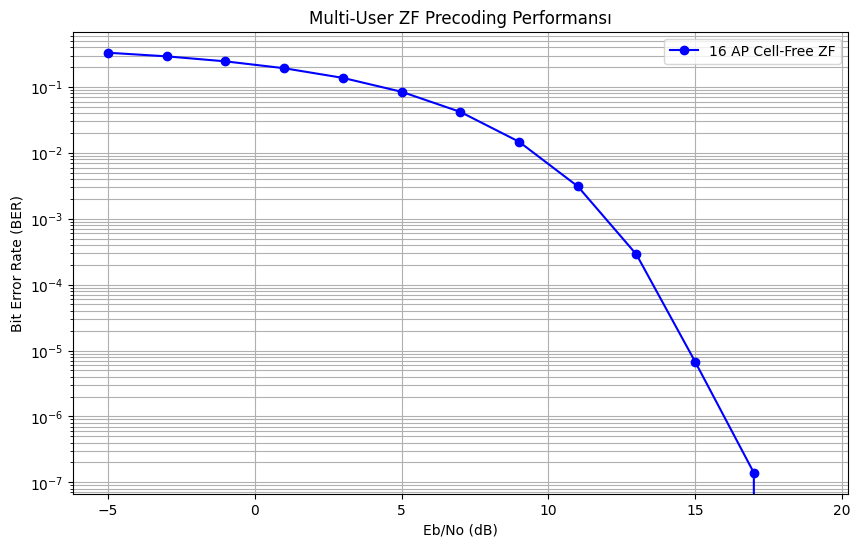

In [14]:
# --- ADIM 1: DEMAPPER VE HAZIRLIK ---
new_demapper = Demapper(demapping_method="app", constellation=constellation)
ebnos_db = np.arange(-5, 20, 2) 
ber_list = []



# --- ADIM 2: GERÇEKÇİ BER vs EbNo TARAMASI ---
for ebno in ebnos_db:
    # 1. Gürültü Varyansını Hesapla
    
    no_v = ebnodb2no(ebno, num_bits_per_symbol=2, coderate=1.0)
    
    # 2. GÜRÜLTÜ EKLEME
    # y_received zaten [2, 14, 128] boyutunda (Havada birleşmiş sinyal)
    noise_std = tf.sqrt(no_v / 2)
    noise = tf.complex(tf.random.normal(tf.shape(y_received), stddev=noise_std),
                       tf.random.normal(tf.shape(y_received), stddev=noise_std))
    
    y_noisy = y_received + noise
    

    # 3. EŞİTLEME (Equalization)
    # [2, 14, 128] / [2, 14, 128] -> Tam uyumlu boyutlar!
    x_hat = y_noisy / tf.cast(g_eff + 1e-12, tf.complex64)
    
    # 4. DEMAPPING
    # 2 UE * 14 Sembol * 128 Taşıyıcı = 3584 toplam sembol.
    # [1, 1, 2, 1792] toplamda 3584 eder, tam oturur.
    x_input = tf.reshape(y_noisy, [batch_size_payload, 1, ue_number, 1792])
    
    # Demapper gürültü seviyesini bilmeli
    l = new_demapper(x_input, tf.cast(tf.fill([1], no_v), tf.float32))
    # QPSK constellation: (1+1j)/sqrt(2), (1-1j)/sqrt(2), (-1+1j)/sqrt(2), (-1-1j)/sqrt(2)


    # 5. BİT TAHMİNİ VE BER HESAPLA
    b_h = tf.cast(l > 0, tf.float32)
    b_f = tf.reshape(b_h, bits.shape)
    
    current_ber = compute_ber(bits, b_f).numpy()
    ber_list.append(current_ber)
    print(f"EbNo: {ebno} dB | BER: {current_ber:.6f}")

# --- ADIM 3: GRAFİK ÇİZİMİ ---
plt.figure(figsize=(10, 6))
plt.semilogy(ebnos_db, ber_list, 'b-o', label='16 AP Cell-Free ZF') # ZF olarak güncelledik
plt.grid(True, which="both")
plt.xlabel('Eb/No (dB)')
plt.ylabel('Bit Error Rate (BER)')
plt.title('Multi-User ZF Precoding Performansı')
plt.legend()
plt.show()




In [15]:
import numpy as np

# Matrisi analiz için temizleyelim (gereksiz boyutları atalım)
# Beklenen yeni boyut: [UE, AP, Path, Time] -> [16, 16, 1, 14] gibi
a_filtered=np.squeeze(a)
a_clean = np.squeeze(a_filtered)

print(f"{'UE No':<6} | {'AP No':<6} | {'Yol Sayısı':<12} | {'Toplam Fiziksel Şiddet':<25}")
print("-" * 65)

for u_idx in range(16):
    found_connection = False
    for ap_idx in range(16):
        # a_clean[u_idx, ap_idx] -> Bu UE ve AP arasındaki tüm yol verisi
        # Boyut hatası almamak için güvenli erişim:
        try:
            path_data = a_clean[u_idx, ap_idx]
        except:
            path_data = a_clean[ap_idx, u_idx] # Boyutlar yer değiştirmişse
            
        # 1. Yol Sayısını Hesapla (Eşiği geçen yollar)
        # path_data genellikle [Path, Time] boyutundadır
        path_magnitudes = np.max(np.abs(path_data), axis=-1) 
        active_paths = np.sum(path_magnitudes > 0)
        
        # 2. Toplam Şiddeti Hesapla
        total_power = np.sum(np.abs(path_data))
        
        # Sadece sinyal olanları veya UE 13 gibi özel durumları yazdır
        if total_power > 0:
            print(f"UE {u_idx:<3} | AP {ap_idx:<3} | {active_paths:<10} | {total_power:.20e}")
            found_connection = True
            
    if not found_connection:
        print(f"UE {u_idx:<3} | --- NO CONNECTION ---")
    
    print("-" * 30) # Her UE arasına bir ayraç

UE No  | AP No  | Yol Sayısı   | Toplam Fiziksel Şiddet   
-----------------------------------------------------------------
UE 0   | AP 1   | 1          | 2.00095710169989615679e-05
------------------------------
UE 1   | --- NO CONNECTION ---
------------------------------
UE 2   | AP 2   | 8          | 7.83252296969294548035e-04
UE 2   | AP 9   | 2          | 9.16590761335100978613e-06
------------------------------
UE 3   | AP 3   | 5          | 3.98841657442972064018e-04
UE 3   | AP 7   | 7          | 1.05547986458986997604e-03
------------------------------
UE 4   | AP 4   | 1          | 9.11493625608272850513e-05
------------------------------
UE 5   | AP 5   | 26         | 3.46019654534757137299e-03
UE 5   | AP 6   | 29         | 3.48835298791527748108e-03
UE 5   | AP 7   | 9          | 4.33731649536639451981e-04
UE 5   | AP 9   | 6          | 2.01723290956579148769e-04
------------------------------
UE 6   | AP 6   | 6          | 9.01650753803551197052e-04
UE 6   | AP 7   | 16

EbNo: -5 dB | Coded BER: 0.404897
EbNo: -3 dB | Coded BER: 0.381669
EbNo: -1 dB | Coded BER: 0.354347
EbNo: 1 dB | Coded BER: 0.323674
EbNo: 3 dB | Coded BER: 0.289772
EbNo: 5 dB | Coded BER: 0.247694
EbNo: 7 dB | Coded BER: 0.010798
EbNo: 9 dB | Coded BER: 0.000010
EbNo: 11 dB | Coded BER: 0.000001
EbNo: 13 dB | Coded BER: 0.000000
EbNo: 15 dB | Coded BER: 0.000000
EbNo: 17 dB | Coded BER: 0.000000
EbNo: 19 dB | Coded BER: 0.000000


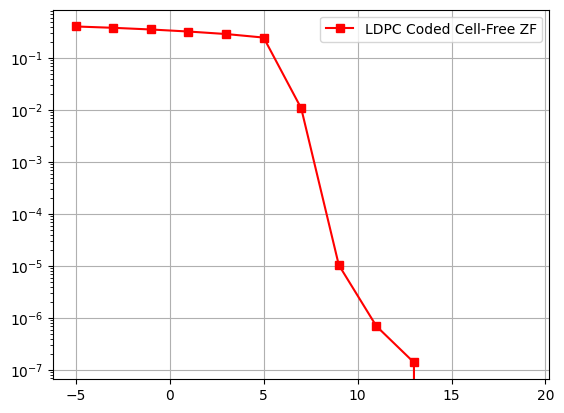

In [17]:
class CellFree_Coding_Model(Block):
    def __init__(self, ue_number, num_tx, fft_size, num_ofdm_symbols, 
                 subcarrier_spacing, constellation, a, tau):
        super().__init__()
        
        # --- Sistem Parametreleri ---
        self.ue_number = ue_number
        self.num_tx = num_tx
        self.constellation = constellation
        self.num_bits_per_symbol = constellation.num_bits_per_symbol
        
        # --- 1. Resource Grid Yapılandırması (Senin orijinal yapın) ---
        self.rg = ResourceGrid(num_ofdm_symbols=num_ofdm_symbols,
                               fft_size=fft_size,
                               subcarrier_spacing=subcarrier_spacing,
                               num_tx=1, # Her stream bağımsız üretilir
                               num_streams_per_tx=self.ue_number,
                               num_guard_carriers=[0, 0],
                               dc_null=False)
        
        self.rg_mapper = ResourceGridMapper(self.rg)
        
        # --- 2. Kanal Kodlama (LDPC) ---
        # Toplam veri sembolü sayısını ResourceGrid'den alıyoruz
        self.n = int(self.rg.num_data_symbols) * self.num_bits_per_symbol
        self.coderate = 0.5
        self.k = int(self.n * self.coderate)
        
        self.binary_source = BinarySource()
        self.encoder = LDPC5GEncoder(self.k, self.n)
        self.decoder = LDPC5GDecoder(self.encoder, num_iter=20)
        self.mapper = Mapper(constellation=self.constellation)
        self.demapper = Demapper("app", constellation=self.constellation)
        
        # --- 3. Kanal Hazırlığı ---
        self.frequencies = subcarrier_frequencies(fft_size, subcarrier_spacing)
        h_freq = cir_to_ofdm_channel(self.frequencies, a, tau, normalize=True)
        # Boyut: [UE, AP, Time, Freq]
        self.h_ue = tf.cast(h_freq[9:9+self.ue_number, 0, 0, :, 0, :, :], tf.complex64)

    def precode_zf(self, H):
        H_ready = tf.transpose(H, [2, 3, 0, 1]) # [14, 128, 4, 16]
        H_hermitian = tf.linalg.adjoint(H_ready)
        gram = tf.matmul(H_ready, H_hermitian)
        last_dim = gram.shape[-1] 
        gram_inv = tf.linalg.inv(gram + tf.eye(last_dim, dtype=tf.complex64) * 1e-9)
        W_matrix = tf.matmul(H_hermitian, gram_inv) 
        w_zf = tf.transpose(W_matrix, [3, 2, 0, 1]) # [4, 16, 14, 128]
        norm_factor = tf.sqrt(tf.reduce_sum(tf.abs(w_zf)**2, axis=[0, 1], keepdims=True))
        return w_zf / tf.cast(norm_factor, tf.complex64)

    @tf.function
    def call(self, batch_size, ebno_db):
        no = ebnodb2no(ebno_db, self.num_bits_per_symbol, self.coderate)
        
        # --- ÜRETİM VE KODLAMA ---
        # bits: [batch, 1, ue, k] (Sionna standartlarına uygun batch yapısı)
        u = self.binary_source([batch_size, 1, self.ue_number, self.k])
        c = self.encoder(u) # [batch, 1, ue, n]
        
        # --- MAPPER VE GRID ---
        x = self.mapper(c) # [batch, 1, ue, num_data_symbols]
        x_rg = self.rg_mapper(x) # [batch, 1, ue, 14, 128]
        # Precoding için 1. boyutu (num_tx=1) düşürelim
        x_signal = tf.squeeze(x_rg, axis=1) # [batch, ue, 14, 128]
        
        # --- ZF PRECODING ---
        w_zf = self.precode_zf(self.h_ue)
        # x_precoded: [batch, ap, 14, 128]
        x_precoded = tf.expand_dims(w_zf, axis=0) * tf.expand_dims(x_signal, axis=2)
        
        # --- KANAL ETKİSİ ---
        y_received = tf.reduce_sum(self.h_ue * x_precoded, axis=2)
        
        # --- GÜRÜLTÜ ---
        noise_std = tf.sqrt(no/2)
        noise = tf.complex(
        tf.random.normal(tf.shape(y_received), stddev=noise_std), # Real kısım
        tf.random.normal(tf.shape(y_received), stddev=noise_std)  # Imaginary kısım
        )
        y_noisy = y_received + tf.cast(noise, tf.complex64)
        
        # --- EQUALIZATION ---
        g_eff = tf.reduce_sum(self.h_ue * w_zf, axis=1) 
        x_hat = y_noisy / tf.cast(g_eff + 1e-12, tf.complex64)
        
        # --- DEMAPPING VE DECODING ---
        # ResourceGrid'den geri çıkarmak için boyutu tekrar ayarla

        x_hat=tf.reshape(x_hat, [batch_size, 1, ue_number, 1792])
        
        llr = self.demapper(x_hat, no)
        
        u_hat = self.decoder(llr) 
        
        return u, u_hat
    



# Model Parametreleri
ue_number = 4 

# Modelin ilklendirilmesi
model_with_coding = CellFree_Coding_Model(
    ue_number=ue_number,
    num_tx=16,
    fft_size=128,
    num_ofdm_symbols=14,
    subcarrier_spacing=30e3,
    constellation=constellation,
    a=a,   # Senin ray-tracing verin
    tau=tau # Senin ray-tracing verin
)

# BER Simülasyonu
ber_coded = []
for ebno in ebnos_db:
    u, u_hat = model_with_coding(batch_size=1000, ebno_db=float(ebno))
    current_ber = compute_ber(u, u_hat).numpy()
    ber_coded.append(current_ber)
    print(f"EbNo: {ebno} dB | Coded BER: {current_ber:.6f}")

# Grafik
plt.semilogy(ebnos_db, ber_coded, 'r-s', label='LDPC Coded Cell-Free ZF')
plt.grid(True)
plt.legend()
plt.show()

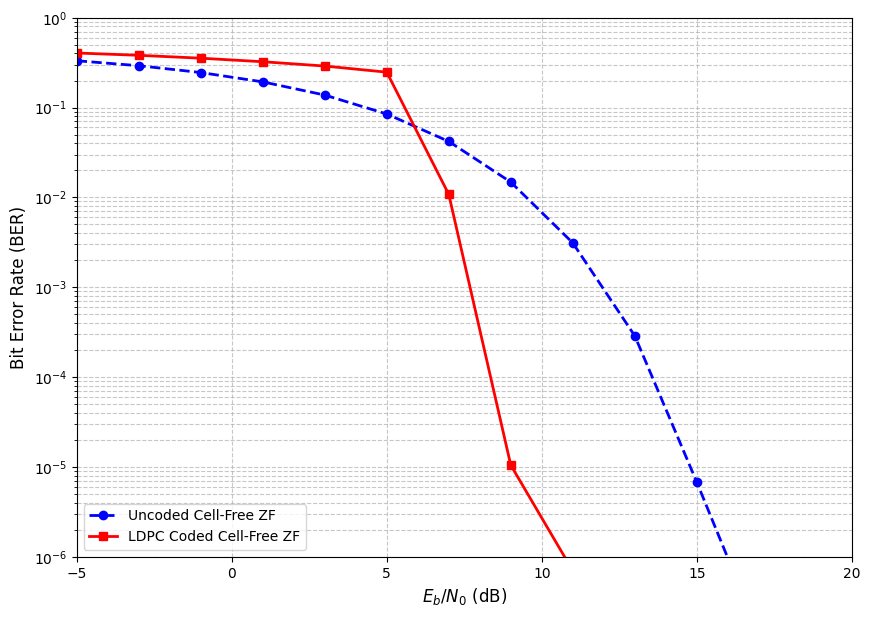

In [19]:
# --- ADIM 3: KARŞILAŞTIRMALI GRAFİK ÇİZİMİ ---
plt.figure(figsize=(10, 7))

# 1. Kodlanmamış (Uncoded) ZF Performansı - Mavi Çizgi
plt.semilogy(ebnos_db, ber_list, 'b--o', linewidth=2, label='Uncoded Cell-Free ZF')

# 2. LDPC Kodlanmış (Coded) ZF Performansı - Kırmızı Çizgi
plt.semilogy(ebnos_db, ber_coded, 'r-s', linewidth=2, label='LDPC Coded Cell-Free ZF')

# Grafik Ayarları
plt.grid(True, which="both", linestyle='--', alpha=0.7)
plt.xlabel('$E_b/N_0$ (dB)', fontsize=12)
plt.ylabel('Bit Error Rate (BER)', fontsize=12)

plt.legend(loc='lower left')

# Eksen sınırlarını BER seviyesine göre ayarlayalım
plt.ylim([1e-6, 1]) 
plt.xlim([-5, 20])

plt.show()